In [1]:
# Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# PCA Libraries
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# KNN Libraries
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap


# Load the dataset
df = pd.read_csv('dataset/googleplaystore_cleaned.csv')

In [2]:
# Handle 'Varies with device' in 'Size' column
df['Size_varies'] = (df['Size'] == 'Varies with device').astype(int)
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

# Fill based on the median size of apps in the same category
df['Size'] = df.groupby('Category')['Size'].transform(
  lambda x: x.fillna(x.median())
)

# Fallback: Fill any remaining NaN values in 'Size' with the overall median
df['Size'].fillna(df['Size'].median(), inplace=True)

In [3]:
df['Size'].median()

np.float64(11264.0)

### Objective 1: Hit or Miss Prediction

Problem: Can we predict if an app will be a hit or a miss based on its features?

In [4]:
# Success dataframe
df['Success'] = (df['Installs'] > 100_000).astype(int)

# Select features and target variable
features = [
  'Category',
  'Size_varies',
  'Size',
  'Type',
  'Price',
  'Content Rating',
]

X = df[features]
y = df['Success']

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True, columns=[
  'Category',
  'Type',
  'Content Rating',
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=67)

# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=67, n_jobs=-1)

# Train the model
rf_classifier.fit(X_train, y_train)

# Predictions
y_pred = rf_classifier.predict(X_test)

In [5]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Miss', 'Hit']))

Classification Report:
              precision    recall  f1-score   support

        Miss       0.73      0.77      0.75      1136
         Hit       0.64      0.60      0.62       796

    accuracy                           0.70      1932
   macro avg       0.69      0.68      0.69      1932
weighted avg       0.70      0.70      0.70      1932



In [6]:
# Examine feature importance
importances = rf_classifier.feature_importances_
feature_names = X_encoded.columns

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

feature_importance_df.head(100)

,Feature,Importance
1,Size,0.587980
0,Size_varies,0.102870
35,Type_Paid,0.037124
2,Price,0.032503
16,Category_GAME,0.025385
22,Category_MEDICAL,0.021480
38,Content Rating_Teen,0.015966
26,Category_PHOTOGRAPHY,0.010954
6,Category_BUSINESS,0.010828
37,Content Rating_Mature 17+,0.010676


#### Application

In [7]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

def predict_app_success(model, training_columns):
    print("\n" + "="*40)
    print("APP SUCCESS PREDICTOR (100k+ Installs)")
    print("="*40)

    # User input for app features
    category = input("Enter App Category (e.g., GAME, PRODUCTIVITY): ").strip().upper()
    app_type = input("Enter App Type (Free/Paid): ").strip().capitalize()
    price = float(input("Enter App Price (e.g., 0.00 for Free): "))
    content_rating = input("Enter Content Rating (e.g., Everyone, Teen): ").strip().capitalize()
    varies = input("Does the app have variable size? (y/n): ").strip().lower()

    input_data = pd.DataFrame(0, index=[0], columns=training_columns)

    if 'Price' in training_columns:
        input_data['Price'] = price

    category_col = f'Category_{category}'
    if category_col in training_columns:
        input_data[category_col] = 1
    
    type_col = f'Type_{app_type}'
    if type_col in training_columns:
        input_data[type_col] = 1

    content_col = f'Content Rating_{content_rating}'
    if content_col in training_columns:
        input_data[content_col] = 1

    if varies == 'y' and 'Size_Varies with device' in training_columns:
        input_data['Size_Varies with device'] = 1

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    print("\n--- RESULTS ---")
    if prediction == 1:
        print(f"Prediction: HIT (High Volume Expected)")
        print(f"Confidence: {probability * 100:.1f}%")
    else:
        print(f"Prediction: FLOP (Niche / Low Volume)")
        print(f"Confidence: {(1 - probability) * 100:.1f}%")
    print("="*40 + "\n")

In [8]:
# Run Script
# while True:
#     predict_app_success(rf_classifier, X_encoded.columns)
#     cont = input("Do you want to predict another app? (y/n): ").strip().lower()
#     if cont != 'y':
#         print("Exiting App Success Predictor. Goodbye!")
#         break

### Objective 2: Principal Component Analysis (PCA)

Problem: Can we reduce the dimensionality of our dataset while retaining most of the variance, and identify the most important features that contribute to the success of an app?

In [9]:
df_pca = df.copy()  # Preserve original

# Log-transform 'Installs' and 'Reviews'
df_pca['Log_Installs'] = np.log1p(df_pca['Installs'] + 1)
df_pca['Log_Reviews'] = np.log1p(df_pca['Reviews'] + 1)
df_pca['Log_Size'] = np.log1p(df_pca['Size'] + 1)

# Continous features Only
continuous_features = [
  'Log_Installs',
  'Rating',
  'Log_Reviews',
  'Price',
  'Log_Size'
]
X_continuous = df_pca[continuous_features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_continuous)

# PCA
pca = PCA()
pca.fit(X_scaled)

variance_ratios = pca.explained_variance_ratio_

In [10]:
variance_ratios_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(variance_ratios))],
    'Variance Ratio': variance_ratios
})
variance_ratios_df

,Principal Component,Variance Ratio
0,PC1,0.477596
1,PC2,0.199748
2,PC3,0.187222
3,PC4,0.126989
4,PC5,0.008445


In [11]:
# cumulative variance for pc1 and pc2

cumulative_variance = sum(variance_ratios[:2]) * 100
print(f"Cumulative Variance Explained by PC1 and PC2: {cumulative_variance:.2f}%")

Cumulative Variance Explained by PC1 and PC2: 67.73%


In [12]:
# Eigenvectors
components_df = pd.DataFrame(
  pca.components_,
  columns=continuous_features,
  index=[f'PC{i+1} (Eigenvector {i+1})' for i in range(len(variance_ratios))]
)

components_df

,Log_Installs,Rating,Log_Reviews,Price,Log_Size
PC1 (Eigenvector 1),0.612849,0.421180,0.614328,-0.053132,0.258461
PC2 (Eigenvector 2),0.032671,0.112500,0.043739,0.978571,-0.163592
PC3 (Eigenvector 3),-0.060188,-0.405452,-0.019320,0.198289,0.890109
PC4 (Eigenvector 4),-0.349710,0.803434,-0.344457,-0.008981,0.336848
PC5 (Eigenvector 5),-0.705287,0.007415,0.708283,-0.013306,-0.025975


#### Interpretation

- PC1 represents the viral reach of an app (Installs, Ratings, Reviews).

- PC2 captures the relationship between Rating and Price, indicating how price affects user ratings. High Price -> Low Rating, and Low Price -> High Rating.

- PC3 is similar to PC2 but in opposite direction.

- PC4 is just the Size of the app, which is not very important.

- PC5 is for Installs and Reviews, which seperate the apps with many installs and reviews from those with few.

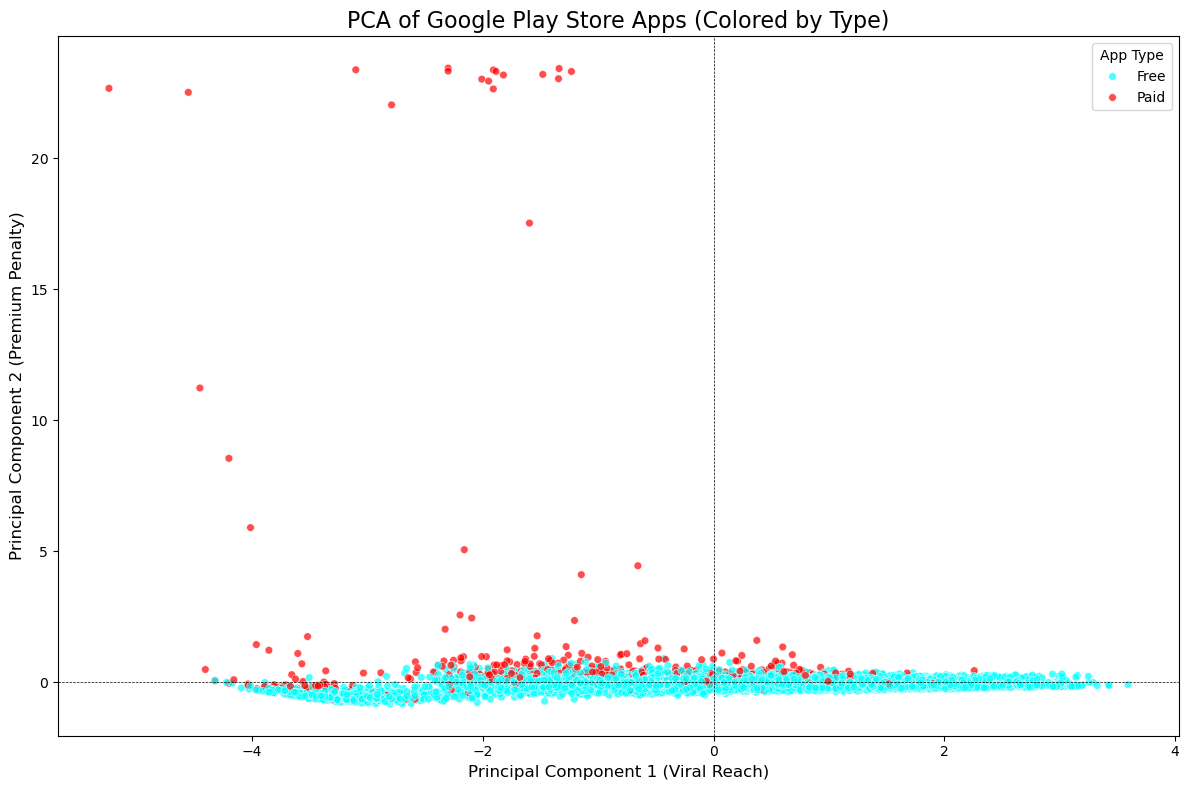

In [13]:
# Plotting the PCA
pca_2d = pca.transform(X_scaled)

pca_df = pd.DataFrame({
  'PC1 (Viral Reach)' : pca_2d[:, 0],
  'PC2 (Premium Penalty)' : pca_2d[:, 1],
  'App_type' : df_pca['Type'],
  'Category' : df_pca['Category']
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
  data=pca_df,
  x='PC1 (Viral Reach)',
  y='PC2 (Premium Penalty)',
  hue='App_type',
  palette={'Free': 'cyan', 'Paid': 'red'},
  alpha=0.7,
  s=30
)

plt.title('PCA of Google Play Store Apps (Colored by Type)', fontsize=16)
plt.xlabel('Principal Component 1 (Viral Reach)', fontsize=12)
plt.ylabel('Principal Component 2 (Premium Penalty)', fontsize=12)
plt.legend(title='App Type')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()

This reveals the map of the app landscape. Notice that there's no red dots in the far-right, which means if an app wants to be a hit, it needs to be free. The paywall act as a barrier to success. 

There are red dots in the upper-left. These are apps like "I'm Rich" or expensive enterprise apps. This shows that high price, leads to lower installs.

At the bottom-center, there are some red dots, suggesting that Paid apps can still be hits, but only if they keep their "Premium Penalty".

#### Subproblem

Identify the following:
1. What are the top performing apps?
2. What are the paid apps that are hits?
3. What are the free apps that are misses?
4. What are the paid apps with low price penalty?
5. What are the paid apps with high price penalty?

In [14]:
pca_df['App_Name'] = df_pca['App'].values
pca_df['Price'] = df_pca['Price'].values
pca_df['Installs'] = df_pca['Installs'].values
pca_df['Size'] = df_pca['Size'].values

pca_df.sort_values(by=['PC1 (Viral Reach)', 'Installs'], ascending=False).head(20)

,PC1 (Viral Reach),PC2 (Premium Penalty),App_type,Category,App_Name,Price,Installs,Size
1356,3.593424,-0.078457,Free,GAME,Subway Surfers,0.0,1000000000,77824.0
1372,3.428826,-0.115418,Free,GAME,Clash of Clans,0.0,100000000,100352.0
1357,3.424809,-0.091313,Free,GAME,Candy Crush Saga,0.0,500000000,75776.0
1362,3.326451,-0.121191,Free,GAME,Clash Royale,0.0,100000000,99328.0
342,3.293373,-0.003198,Free,COMMUNICATION,UC Browser - Fast Download Private & Secure,0.0,500000000,40960.0
1410,3.256374,0.001749,Free,GAME,My Talking Tom,0.0,500000000,38912.0
2003,3.250662,0.231753,Free,SOCIAL,Instagram,0.0,1000000000,8089.6
1363,3.200689,-0.087655,Free,GAME,Temple Run 2,0.0,500000000,63488.0
1527,3.193344,-0.116274,Free,GAME,Shadow Fight 2,0.0,100000000,90112.0
1399,3.168778,-0.141972,Free,GAME,My Talking Angela,0.0,100000000,101376.0


In [15]:
# 1. Map the original app names, prices, and installs back into our PCA DataFrame

# 2. Filter for the extreme mathematical outliers (The top-left cluster)
extreme_outliers = pca_df[pca_df['PC2 (Premium Penalty)'] > 10]

# 3. Sort them from most extreme to least extreme
top_outliers = extreme_outliers.sort_values(by='PC2 (Premium Penalty)', ascending=False)

# 4. Print the exact details
print("\n--- THE 'EXTREME PREMIUM' OUTLIERS ---")
top_outliers[['App_Name', 'Category', 'Price', 'Installs']].head(25)


--- THE 'EXTREME PREMIUM' OUTLIERS ---


,App_Name,Category,Price,Installs
4403,I am rich(premium),FINANCE,399.99,5000
4396,I am rich,LIFESTYLE,399.99,100000
3327,most expensive app (H),FAMILY,399.99,100
4406,I Am Rich Pro,FAMILY,399.99,5000
4408,I am rich (Most expensive app),FINANCE,399.99,1000
4413,I am Rich,FINANCE,399.99,5000
4400,I Am Rich Premium,FINANCE,399.99,50000
4398,I am Rich Plus,FAMILY,399.99,10000
3469,I'm Rich - Trump Edition,LIFESTYLE,400.00,10000
3465,💎 I'm rich,LIFESTYLE,399.99,10000


### KNN Classifier for PCA Clusters
To classify apps into hits and misses based on their PCA components, we can use a K-Nearest Neighbors (KNN) classifier. 

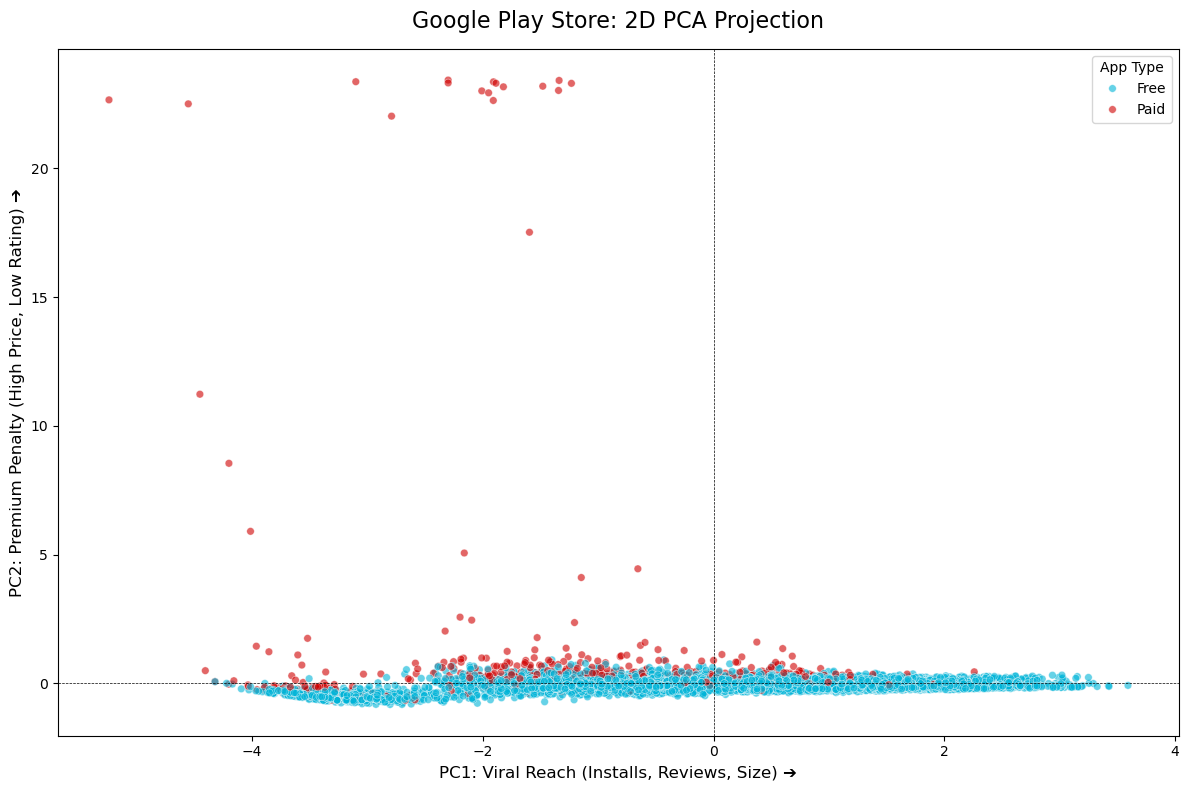

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Transform the 5D data into 2D coordinates using your fitted PCA model
X_pca_2d = pca.transform(X_scaled)

# 2. Create a new DataFrame with the coordinates and the labels we want to color by
pca_df = pd.DataFrame({
    'PC1 (Viral Reach)': X_pca_2d[:, 0],
    'PC2 (Premium Penalty)': X_pca_2d[:, 1],
    'App_Type': df_pca['Type'],
    'Category': df_pca['Category']
})

# 3. Plot the PCA Scatter
plt.figure(figsize=(12, 8))

# We will color the dots by whether they are Free or Paid
sns.scatterplot(
    data=pca_df, 
    x='PC1 (Viral Reach)', 
    y='PC2 (Premium Penalty)', 
    hue='App_Type', 
    palette={'Free': '#00B4D8', 'Paid': '#D00000'},
    alpha=0.6,
    s=30
)

# 4. Clean up the aesthetics
plt.title('Google Play Store: 2D PCA Projection', fontsize=16, pad=15)
plt.xlabel('PC1: Viral Reach (Installs, Reviews, Size) ➔', fontsize=12)
plt.ylabel('PC2: Premium Penalty (High Price, Low Rating) ➔', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend(title='App Type', loc='upper right')
plt.tight_layout()

# Render it in your Kitty terminal / image viewer
plt.show()

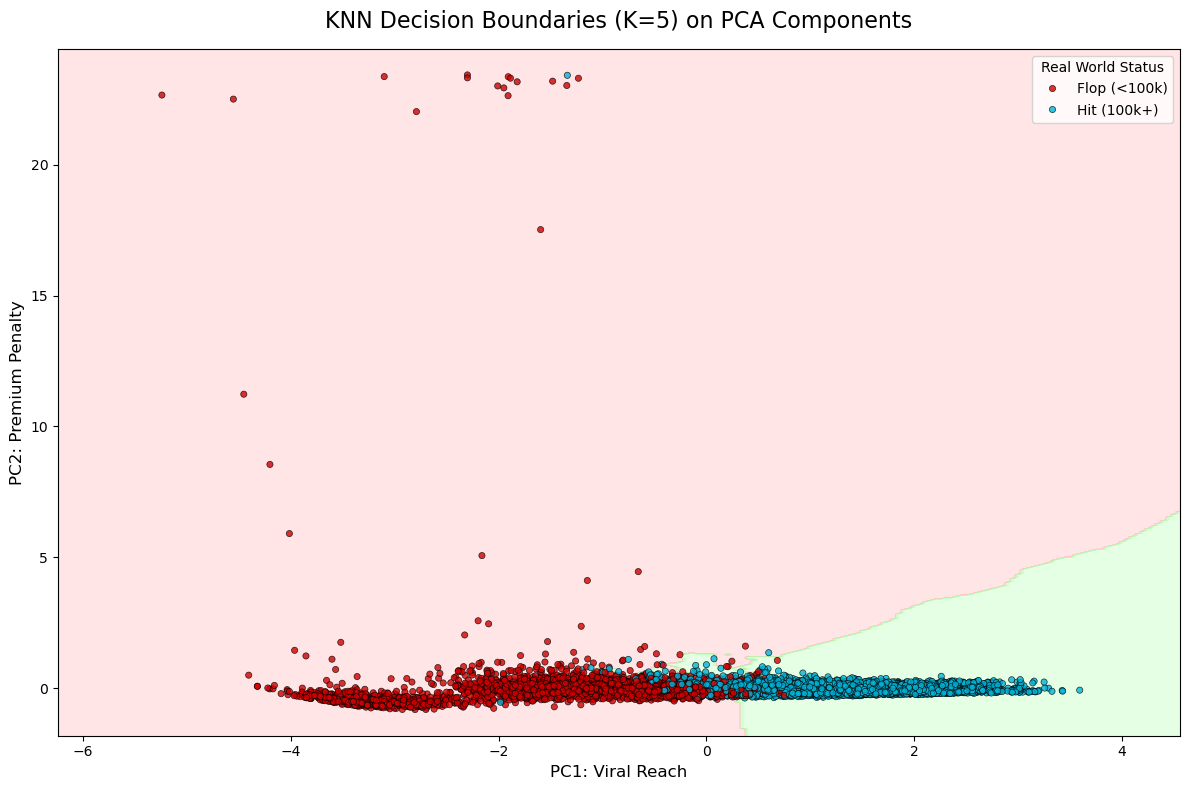

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

# 1. Define your isolated 2D Features (X) and Target (y)
# FIX: Explicitly slice the array to only grab PC1 (index 0) and PC2 (index 1)
X_knn = X_pca_2d[:, :2]  
y_knn = (df_pca['Installs'] >= 100000).astype(int)

# 2. Initialize and fit the KNN Classifier
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_knn, y_knn)

# 3. Build the Meshgrid (The background prediction canvas)
h = 0.05  
x_min, x_max = X_knn[:, 0].min() - 1, X_knn[:, 0].max() + 1
y_min, y_max = X_knn[:, 1].min() - 1, X_knn[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 4. Predict the entire grid to map the territory
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Render the Visualization
plt.figure(figsize=(12, 8))

cmap_background = ListedColormap(['#FFAAAA', '#AAFFAA']) 
cmap_points = {0: '#D00000', 1: '#00B4D8'} 

plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.3)

sns.scatterplot(
    x=X_knn[:, 0], 
    y=X_knn[:, 1], 
    hue=y_knn, 
    palette=cmap_points, 
    alpha=0.8, 
    s=20,
    edgecolor='k',
    linewidth=0.5
)

plt.title(f'KNN Decision Boundaries (K={k}) on PCA Components', fontsize=16, pad=15)
plt.xlabel('PC1: Viral Reach', fontsize=12)
plt.ylabel('PC2: Premium Penalty', fontsize=12)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Flop (<100k)', 'Hit (100k+)'], title='Real World Status')

plt.tight_layout()
plt.show()

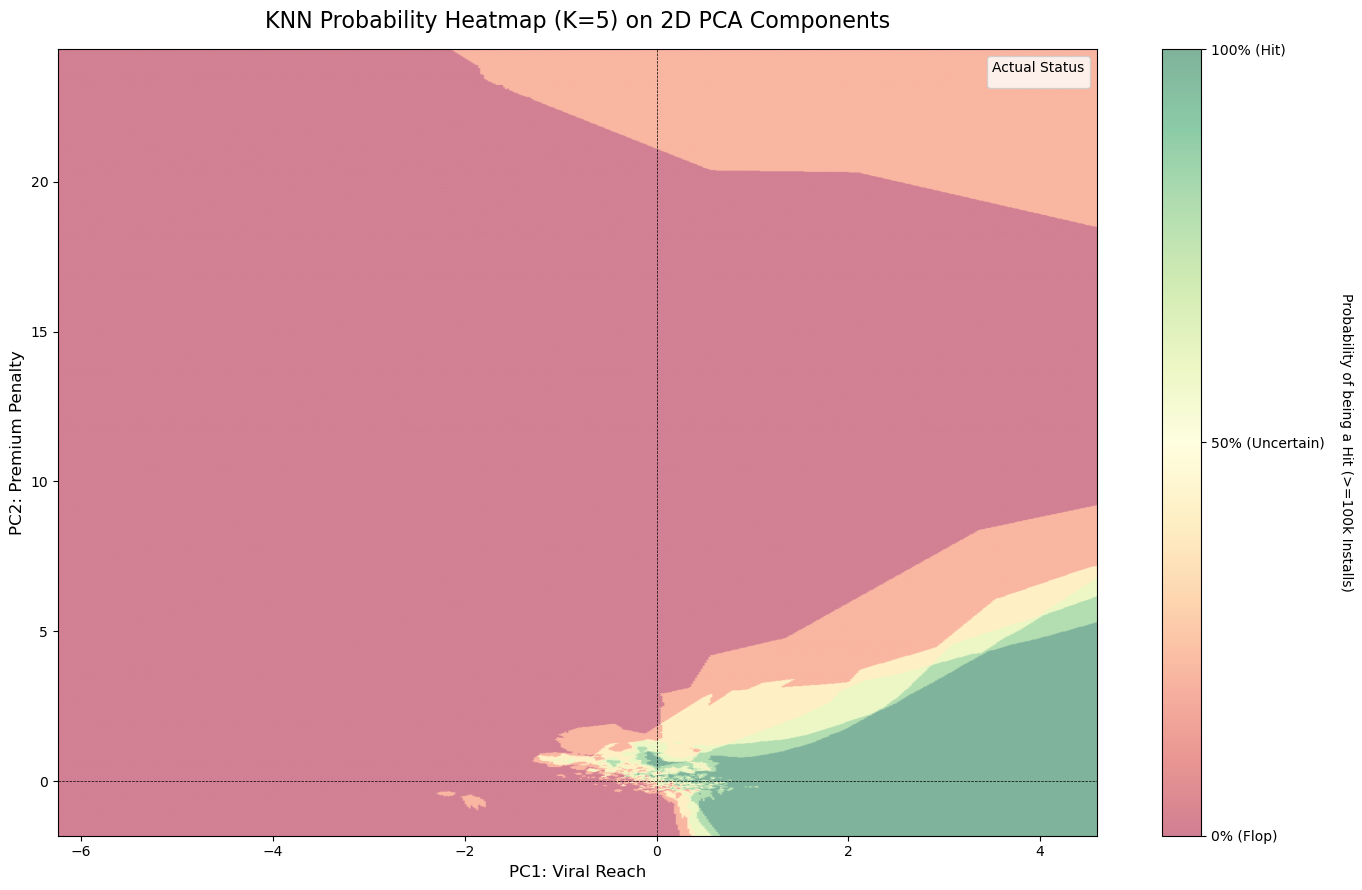

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

# 1. Define 2D Features (X) and Target (y) using PCA Slicing
# Ensure X_pca_2d from previous step is loaded
X_knn = X_pca_2d[:, :2]  
y_knn = (df_pca['Installs'] >= 100000).astype(int)

# 2. Fit the KNN Classifier (Keeping K=5)
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_knn, y_knn)

# 3. Build the Meshgrid (Increase resolution slightly for smoother heatmap)
h = 0.02  # Higher resolution (smaller step) makes for a smoother gradient
x_min, x_max = X_knn[:, 0].min() - 1, X_knn[:, 0].max() + 1
y_min, y_max = X_knn[:, 1].min() - 1, X_knn[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 4. Predict PROBABILITIES instead of Classes (The Heatmap Math)
# predict_proba returns [prob_class_0, prob_class_1]
# We only want the probability of being a Hit (index 1)
Z_prob = knn.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z_prob = Z_prob.reshape(xx.shape)

# 5. Render the Visualization
plt.figure(figsize=(14, 9))

# Plot the continuous probability heatmap using imshow
# extent maps the coordinates correctly, RdYlGn gives Red(0)-Yellow(0.5)-Green(1)
heatmap = plt.imshow(Z_prob, extent=(x_min, x_max, y_min, y_max), 
                     cmap='RdYlGn', alpha=0.5, origin='lower', aspect='auto')

# Add a Colorbar to explain the probability gradient
cbar = plt.colorbar(heatmap)
cbar.set_label('Probability of being a Hit (>=100k Installs)', rotation=270, labelpad=20)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['0% (Flop)', '50% (Uncertain)', '100% (Hit)'])

# Overlay the actual data points (using the discrete color map from before)
cmap_points = {0: '#D00000', 1: '#00B4D8'} 
# sns.scatterplot(
#     x=X_knn[:, 0], 
#     y=X_knn[:, 1], 
#     hue=y_knn, 
#     palette=cmap_points, 
#     alpha=0.6, 
#     s=15, # smaller points to let the heatmap shine
#     edgecolor='none'
# )

# Aesthetics
plt.title(f'KNN Probability Heatmap (K={k}) on 2D PCA Components', fontsize=16, pad=15)
plt.xlabel('PC1: Viral Reach', fontsize=12)
plt.ylabel('PC2: Premium Penalty', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')

# Clean legend for the data points
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Real Flop', 'Real Hit'], title='Actual Status')

plt.tight_layout()
plt.show()

In [19]:
# KNN report
# Fix: split before fitting
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.2, random_state=67)
knn.fit(X_train_knn, y_train_knn)
print(classification_report(y_test_knn, knn.predict(X_test_knn)))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       901
           1       0.94      0.92      0.93      1031

    accuracy                           0.92      1932
   macro avg       0.92      0.93      0.92      1932
weighted avg       0.93      0.92      0.93      1932

